In [1]:
%matplotlib widget


import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import tqdm
import quadpy
from mpl_toolkits.mplot3d import Axes3D

from pathlib import Path
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler

In [2]:
MODE_GRIDS_FILENAME = Path(
    "/home/nbyrnes/code/random-matrix/paper_data/mode_grids_rectangular.pkl"
)
with MODE_GRIDS_FILENAME.open("rb") as f:
    mode_grids = pickle.load(f)

In [3]:
first = [
    "pp,pp",
    "pp,pe",
    "pp,ep",
    "pp,ee",
    "pe,pe",
    "pe,pe",
    "pe,ep",
    "pe,ee",
    "ep,ep",
    "ep,ee",
    "ee,ee",
]
second = [
    "t,t",
    "t,r",
    "t,t2",
    "t,r2",
    "r,r",
    "r,t2",
    "r,r2",
    "t2,t2",
    "t2,r2",
    "r2,r2",
]

101


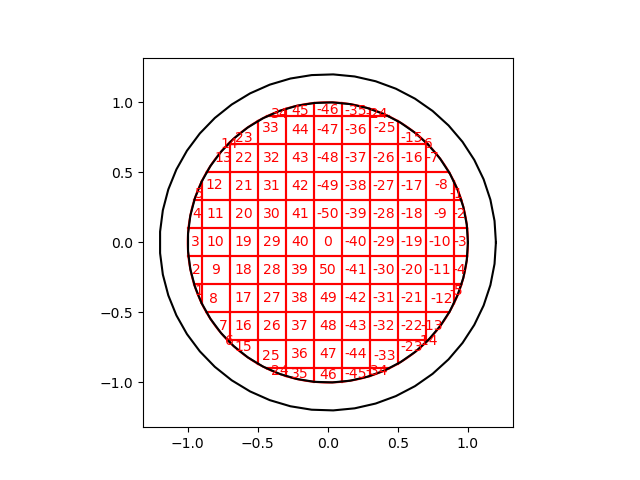

In [ ]:
my_grid = mode_grids[0]
print(my_grid.num_propagating)
my_grid.plot(close=False, show_indices=True)



In [5]:
wavelength = 550e-9
slab_thickness = 1.8992695221776513e-06
number_density = 5.921762640653617e17
medium_parameters = MediumParameters(
    wavelength=wavelength,
    number_density=number_density,
    slab_thickness=slab_thickness,
)
term = DensityFunctionTerm.from_delta({"x": 2, "m": 1.2})

# 2D version
particle_statistics = ParticleStatistics(
    term,
    isotropic_sphere.get_A,
    isotropic_sphere.get_A_product,
    isotropic_sphere.get_A_product_conj,
)
medium_statistics = MediumStatistics([particle_statistics])


# Set up the relevant indices
propagating_indices = my_grid.propagating_indices
quads_a = [(j, incident_index, j, incident_index) for j in propagating_indices]
quads_b = [
    (-incident_index, j, -incident_index, j) for j in propagating_indices
]
quads = quads_a + quads_b
supplied_indices = {
    "covariance": {key1: {key2: [] for key2 in second} for key1 in first},
    "mean": {},
}
for key in ["t,t", "r,r"]:
    supplied_indices["covariance"]["pp,pp"][key] = quads

In [6]:
# 2D NUMPY
use_np_config = IntegrationTaskConfig(use_gpu=False)

simulation_name = f"test_one"
input_statistics_manager = InputStatisticsManager(
    simulation_name,
    medium_parameters,
    medium_statistics,
    my_grid,
    supplied_indices=None,
    use_dirac_density=False,
    integration_method="cubature",
    covariance_cubature_scheme=None,
    integration_task_config=use_np_config,
)
integration_result_list, duration = input_statistics_manager.get_statistics()

/tmp/ipykernel_2357540/4107190123.py:5: UserWarning: No parent_data_dir provided. Defaulting to current working directory: /home/nbyrnes/code/random-matrix/data.
  input_statistics_manager = InputStatisticsManager(


[08/25 17:19:32] Find independent elements


100%|██████████| 101/101 [00:00<00:00, 25632.28it/s]

[08/25 17:19:32] Done
[08/25 17:19:32] Calculate mean indices



100%|██████████| 101/101 [00:00<00:00, 903250.97it/s]

...

[08/25 17:19:48] Prepare mean tasks


100%|██████████| 101/101 [00:00<00:00, 203.94it/s]


[08/25 17:19:48] Done
[08/25 17:19:48] Prepare covariance tasks


  0%|          | 0/4675 [00:00<?, ?it/s]/home/nbyrnes/code/random-matrix/random_matrix/input_statistics/integration_task.py:672: RuntimeWarning: invalid value encountered in sqrt
  sec_factor = 1.0 / xp.abs(np.sqrt(ki_z * kj_z * ku_z * kv_z))
  1%|          | 49/4675 [33:09<12:27:17,  9.69s/it]  /home/nbyrnes/code/random-matrix/random_matrix/amplitude_matrix/scattering_geometry.py:30: RuntimeWarning: invalid value encountered in divide
  e_phi /= mod_kappa[..., xp.newaxis]
/home/nbyrnes/code/random-matrix/random_matrix/amplitude_matrix/scattering_geometry.py:44: RuntimeWarning: invalid value encountered in divide
  e_theta /= xp.sqrt(
100%|██████████| 4675/4675 [5:37:16<00:00,  4.33s/it]   


[08/25 22:57:06] Done


In [7]:
cov_result_list = integration_result_list.by_statistic_type("covariance")

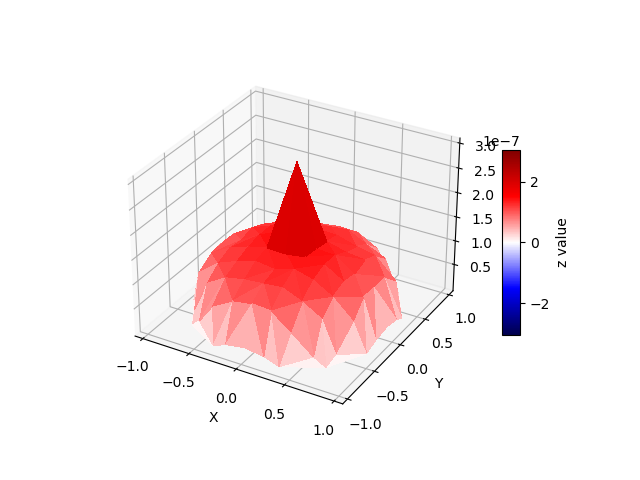

In [16]:
# Example: grid data
incident_index = 0
x = []
y = []
z_f = []
z_b = []
for i in my_grid.propagating_indices:
    r_f = cov_result_list.get(
        "covariance", "pp,pp", "t,t", (i, incident_index, i, incident_index)
    )

    if i >= 0:
        r_b = cov_result_list.get(
            "covariance",
            "pp,pp",
            "r,r",
            (i, incident_index, i, incident_index),
        )
    else:
        r_b = cov_result_list.get(
            "covariance",
            "pp,pp",
            "r,r",
            (-incident_index, -i, -incident_index, -i),
        )

    norm_f = np.linalg.norm(r_f.integral)
    # norm_b = np.linalg.norm(r_b.integral)

    x.append(my_grid.by_index(i).center[0])
    y.append(my_grid.by_index(i).center[1])
    z_f.append(norm_f)
    # z_b.append(-norm_b)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

z_max = np.max(np.abs(np.concatenate([z_f, z_b])))

# Positive surface
surf_pos = ax.plot_trisurf(
    x,
    y,
    z_f,
    cmap="seismic",  # diverging colormap
    linewidth=0,
    antialiased=False,
    vmin=-z_max,
    vmax=z_max,
)

# # Negative surface
# surf_neg = ax.plot_trisurf(
#     x,
#     y,
#     z_b,
#     cmap="seismic",
#     linewidth=0,
#     antialiased=False,
#     vmin=-z_max,
#     vmax=z_max,
# )

# Colorbar
mappable = plt.cm.ScalarMappable(cmap="seismic")
mappable.set_array(np.concatenate([z_f, z_b]))
mappable.set_clim(-z_max, z_max)
fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, label="z value")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

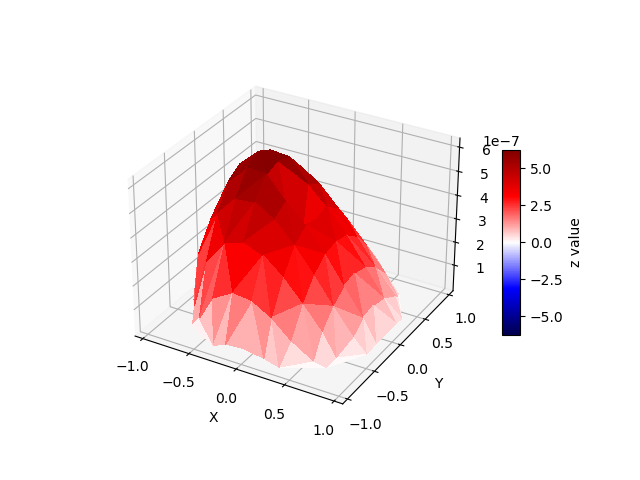

In [17]:
# Example: grid data
incident_index = 40
x = []
y = []
z_f = []
z_b = []
for i in my_grid.propagating_indices:
    r_f = cov_result_list.get(
        "covariance", "pp,pp", "t,t", (i, incident_index, i, incident_index)
    )

    if i >= 0:
        r_b = cov_result_list.get(
            "covariance",
            "pp,pp",
            "r,r",
            (i, incident_index, i, incident_index),
        )
    else:
        r_b = cov_result_list.get(
            "covariance",
            "pp,pp",
            "r,r",
            (-incident_index, -i, -incident_index, -i),
        )

    norm_f = np.linalg.norm(r_f.integral)
    # norm_b = np.linalg.norm(r_b.integral)

    x.append(my_grid.by_index(i).center[0])
    y.append(my_grid.by_index(i).center[1])
    z_f.append(norm_f)
    # z_b.append(-norm_b)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

z_max = np.max(np.abs(np.concatenate([z_f, z_b])))

# Positive surface
surf_pos = ax.plot_trisurf(
    x,
    y,
    z_f,
    cmap="seismic",  # diverging colormap
    linewidth=0,
    antialiased=False,
    vmin=-z_max,
    vmax=z_max,
)

# # Negative surface
# surf_neg = ax.plot_trisurf(
#     x,
#     y,
#     z_b,
#     cmap="seismic",
#     linewidth=0,
#     antialiased=False,
#     vmin=-z_max,
#     vmax=z_max,
# )

# Colorbar
mappable = plt.cm.ScalarMappable(cmap="seismic")
mappable.set_array(np.concatenate([z_f, z_b]))
mappable.set_clim(-z_max, z_max)
fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, label="z value")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

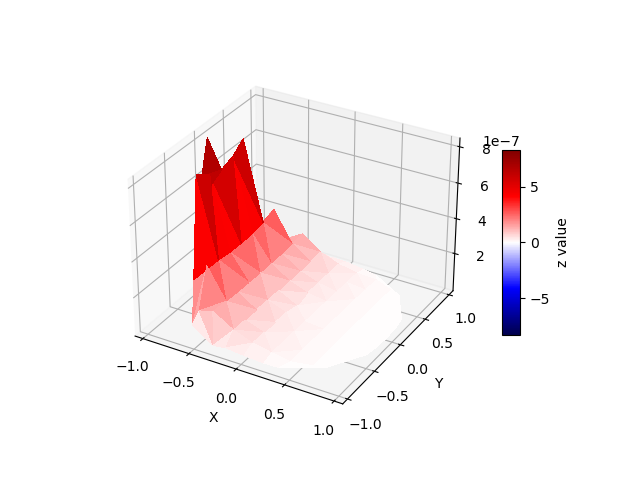

In [18]:
# Example: grid data
incident_index = 3
x = []
y = []
z_f = []
z_b = []
for i in my_grid.propagating_indices:
    r_f = cov_result_list.get(
        "covariance", "pp,pp", "t,t", (i, incident_index, i, incident_index)
    )

    if i >= 0:
        r_b = cov_result_list.get(
            "covariance",
            "pp,pp",
            "r,r",
            (i, incident_index, i, incident_index),
        )
    else:
        r_b = cov_result_list.get(
            "covariance",
            "pp,pp",
            "r,r",
            (-incident_index, -i, -incident_index, -i),
        )

    norm_f = np.linalg.norm(r_f.integral)
    # norm_b = np.linalg.norm(r_b.integral)

    x.append(my_grid.by_index(i).center[0])
    y.append(my_grid.by_index(i).center[1])
    z_f.append(norm_f)
    # z_b.append(-norm_b)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

z_max = np.max(np.abs(np.concatenate([z_f, z_b])))

# Positive surface
surf_pos = ax.plot_trisurf(
    x,
    y,
    z_f,
    cmap="seismic",  # diverging colormap
    linewidth=0,
    antialiased=False,
    vmin=-z_max,
    vmax=z_max,
)

# # Negative surface
# surf_neg = ax.plot_trisurf(
#     x,
#     y,
#     z_b,
#     cmap="seismic",
#     linewidth=0,
#     antialiased=False,
#     vmin=-z_max,
#     vmax=z_max,
# )

# Colorbar
mappable = plt.cm.ScalarMappable(cmap="seismic")
mappable.set_array(np.concatenate([z_f, z_b]))
mappable.set_clim(-z_max, z_max)
fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, label="z value")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [ ]:
print(
    np.linalg.norm(
        cov_result_list.get(
            "covariance", "pp,pp", "t,t", (0, 0, 0, 0)
        ).integral
    )
)
print(
    np.linalg.norm(
        cov_result_list.get(
            "covariance", "pp,pp", "t,t", (40, 0, 40, 0)
        ).integral
    )
)
print(
    np.linalg.norm(
        cov_result_list.get(
            "covariance", "pp,pp", "t,t", (29, 0, 29, 0)
        ).integral
    )
)
print(
    np.linalg.norm(
        cov_result_list.get(
            "covariance", "pp,pp", "t,t", (19, 0, 19, 0)
        ).integral
    )
)
print(
    np.linalg.norm(
        cov_result_list.get(
            "covariance", "pp,pp", "t,t", (10, 0, 10, 0)
        ).integral
    )
)
print(
    np.linalg.norm(
        cov_result_list.get(
            "covariance", "pp,pp", "t,t", (11, 0, 11, 0)
        ).integral
    )
)

AttributeError: 'NoneType' object has no attribute 'integral'

In [ ]:
assert False
r = integration_result_list.results[0]
print(r.block_location == ("pp,pp", "t,r"))
print(r.sub_block_locations)
print(r.integral.shape)

AssertionError: 

In [ ]:
num_propagating = my_grid.num_propagating
counts = np.zeros(num_propagating)
data = np.zeros((num_propagating, num_propagating, 4, 4), dtype=np.complex128)
for r in integration_result_list.results:
    first, second = r.block_location
    if (
        not first == "pp,pp"
        or not second in ["t,t"]
        or len(r.sub_block_locations) == 0
    ):
        continue
    H = r.integral.reshape(4, 4)
    j, i, _, _ = r.sub_block_locations[0]
    data[j, i, :, :] += H
    counts[i] += 1

In [ ]:
summed = np.sum(data, axis=0)
sums = [np.linalg.norm(H) for H in summed]
plt.hist(sums, bins=100, edgecolor="black", density=True)
plt.xlim(np.min(sums), np.max(sums))

In [ ]:
i = 0
for j in propagating_indices:
    


In [ ]:
my_grid.propagating_indices

In [ ]:
print(H1 - np.conj(H1.T))

In [ ]:
with open("data/test_auto_correlations/integration_time.pkl", "rb") as file:
    data = pickle.load(file)

print(data)

31570.963783493266


In [ ]:
with open(
    "/home/nbyrnes/code/random-matrix/paper_data/data/2d_np_rectangular_dirac_101/integration_result_list.pkl",
    "rb",
) as file:
    data = pickle.load(file)

print(data)

Number of results: 36175
Results key:
0, mean, 1 integrals, ('pp', 't')
1, mean, 1 integrals, ('pp', 'r')
2, mean, 1 integrals, ('pp', 'r2')
3, mean, 1 integrals, ('pp', 't')
4, mean, 1 integrals, ('pp', 't')
5, mean, 1 integrals, ('pp', 'r')
6, mean, 1 integrals, ('pp', 'r2')
7, mean, 1 integrals, ('pp', 't')
8, mean, 1 integrals, ('pp', 't')
9, mean, 1 integrals, ('pp', 'r')
10, mean, 1 integrals, ('pp', 'r2')
11, mean, 1 integrals, ('pp', 't')
12, mean, 1 integrals, ('pp', 'r')
13, mean, 1 integrals, ('pp', 'r2')
14, mean, 1 integrals, ('pp', 't')
15, mean, 1 integrals, ('pp', 'r')
16, mean, 1 integrals, ('pp', 'r2')
17, mean, 1 integrals, ('pp', 't')
18, mean, 1 integrals, ('pp', 't')
19, mean, 1 integrals, ('pp', 't')
20, mean, 1 integrals, ('pp', 'r')
21, mean, 1 integrals, ('pp', 'r2')
22, mean, 1 integrals, ('pp', 't')
23, mean, 1 integrals, ('pp', 'r')
24, mean, 1 integrals, ('pp', 'r2')
25, mean, 1 integrals, ('pp', 't')
26, mean, 1 integrals, ('pp', 'r')
27, mean, 1 integral

In [ ]:
data.results[0].integral

array([[8.12411427e-04-3.79113580e-03j, 1.15670442e-36-1.37288678e-35j,
        1.86112951e-36-1.95735764e-35j, 8.12411427e-04-3.79113580e-03j]])